# EIA Thermoelectric Cooling Data (2014 - 2024)

# `03_forensic_clean_for_analysis.ipynb`

**Author:** Amy Zhang  
**AI Collaborators:** ChatGPT, Claude Code, Perplexity AI  
**Date:** January 2026

---
## Table of Contents

1. Import Libraries & Dataset  
2. Water Metrics: Validation of Formula Reconstruction for `intensity` and `rate_per_fuel_consumption` Columns (Conclusion: Correct)  
   2a) `derived_withdrawal_per_fuel_gallons_mmbtu` (new) v. `water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu` (original)    
   2b) `derived_consumption_per_fuel_gallons_mmbtu` (new) v. `water_consumption_rate_per_fuel_consumption_gallons__mmbtu` (original)  
3. Exploring Reporting Inconsistencies    
   3a) Water Consumption-Only Rows (Conclusion: Plausible)  
   3b) Negative Value Rows (Decision: Remove)  
   3c) Neither Water Metric  
       3c1) Remove Structurally Explained Rows (`cooling_type_923` is `NaN` or `DC`)  
       3c2) Explore Remaining Rows with Missing Water Metrics: Plant-Level Investigation  
       3c3) Conclusion: Remove Rows with Neither Water Metric
4. Save `analysis_ready_df.csv`  

---
# 1. Import Libraries & Dataset

In [1]:
# 1. Auto-reload external modules (during development)
%load_ext autoreload
%autoreload 2

# 2. Standard library
import os
import re

# 3. Third party  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from pathlib import Path


In [2]:
from scripts.utils import coverage_summary, coverage_heatmap, column_profile, save_df

In [3]:
csv_file_path = '../data_exports/cooling_melted_df.csv'                          
melted_df = pd.read_csv(csv_file_path)
print(melted_df.dtypes.to_string())

/var/folders/0t/y1sp06bd67v24njwrd0_ch980000gn/T/ipykernel_32089/2121777311.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  melted_df = pd.read_csv(csv_file_path)


utility_id                                                      int64
state                                                          object
plant_code                                                      int64
plant_name                                                     object
year                                                            int64
month                                                           int64
generator_id                                                   object
boiler_id                                                      object
cooling_id                                                     object
generator_primary_technology                                   object
coal_consumption_mmbtu                                        float64
natural_gas_consumption_mmbtu                                 float64
petroleum_consumption_mmbtu                                   float64
biomass_consumption_mmbtu                                     float64
other_gas_consumptio

---
# 2. Water Metrics: Validation of Formula Reconstruction
## 2a) `derived_withdrawal_per_fuel_gallons_mmbtu` v. `water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu`

In [4]:
# 1. Subset to the comparison universe (withdrawal per fuel)

mask = (
    melted_df['water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu'].notna() &
    melted_df['derived_withdrawal_per_fuel_gallons_mmbtu'].notna()
)

wf = melted_df.loc[mask].copy()

print(f"Rows with both reported and derived withdrawal-per-fuel: {len(wf):,}")

# 2. Absolute difference

wf['abs_diff'] = (
    wf['derived_withdrawal_per_fuel_gallons_mmbtu'] -
    wf['water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu']
).abs()


# 3. Quick peek at extremes

wf.sort_values('abs_diff', ascending=False).head(10)[
    [
        'plant_code', 'generator_id', 'cooling_id',
        'technology_type', 'relationship_type',
        'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu',
        'derived_withdrawal_per_fuel_gallons_mmbtu',
        'abs_diff'
    ]
]


Rows with both reported and derived withdrawal-per-fuel: 53,945


,plant_code,generator_id,cooling_id,technology_type,relationship_type,water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu,derived_withdrawal_per_fuel_gallons_mmbtu,abs_diff
367465,6213,2,2CW,steam_turbine,Simple,1.363670e+11,1.317305e+11,4.636477e+09
778980,3611,1,1,steam_turbine,Simple,1.217891e+09,1.309233e+09,9.134186e+07
624128,8042,1,1,steam_turbine,Simple,1.793916e+09,1.734119e+09,5.979720e+07
366436,6106,1,1CS,steam_turbine,Simple,1.681743e+09,1.634093e+09,4.764937e+07
701178,6106,1,1CS,steam_turbine,Simple,1.654419e+09,1.607544e+09,4.687521e+07
701177,6106,1,1CS,steam_turbine,Simple,1.632053e+09,1.585811e+09,4.624150e+07
701179,6106,1,1CS,steam_turbine,Simple,1.631556e+09,1.585329e+09,4.622743e+07
366435,6106,1,1CS,steam_turbine,Simple,1.602099e+09,1.583408e+09,1.869115e+07
444349,3611,2,2,steam_turbine,Simple,4.859819e+08,5.015333e+08,1.555142e+07
691483,3264,3,3,steam_turbine,Simple,5.296933e+08,5.450544e+08,1.536111e+07


In [5]:
wf['abs_diff'].describe(
    percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]
)

count    5.394500e+04
mean     9.611078e+04
std      1.997288e+07
min      0.000000e+00
1%       0.000000e+00
5%       1.647466e-02
10%      4.233234e-02
50%      2.531817e-01
90%      4.649433e-01
95%      4.919486e-01
99%      2.381058e+01
max      4.636477e+09
Name: abs_diff, dtype: float64

In [6]:
# Relative difference (normalized)

wf['rel_diff'] = (
    wf['abs_diff'] /
    wf['water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu'].abs()
)

In [7]:
# Define consistent rows
wf['consistent_rate'] = wf['abs_diff'] <= 1

In [8]:
# Subset only the inconsistent rows
wf_inconsistent = wf.loc[~wf['consistent_rate']].copy()

print(f"Inconsistent rows: {len(wf_inconsistent):,}")

Inconsistent rows: 1,296


In [9]:
cols_needed = [
    'plant_code', 'generator_id', 'cooling_id',
    'technology_type', 'relationship_type',
    'fuel_consumption_mmbtu', 'water_withdrawal_volume_million_gallons',
    'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu',
    'derived_withdrawal_per_fuel_gallons_mmbtu', 'abs_diff', 'rel_diff'
]

In [10]:
with pd.option_context('display.max_columns', None):
    print(wf_inconsistent[cols_needed].head())

      plant_code generator_id cooling_id technology_type relationship_type  \
1945         315            3          3   steam_turbine            Simple   
2064         356            5          5   steam_turbine            Simple   
2076         356            6          6   steam_turbine            Simple   
2091         356            8          8   steam_turbine            Simple   
2893         400            2          2   steam_turbine            Simple   

      fuel_consumption_mmbtu  water_withdrawal_volume_million_gallons  \
1945                  2399.0                                  322.320   
2064                    42.0                                  327.006   
2076                  2913.0                                  452.436   
2091                  7802.0                                  835.380   
2893                 26161.0                                 3845.000   

      water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu  \
1945                     

In [11]:
wf_inconsistent['rel_diff'].describe(
    percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]
)

count    1296.000000
mean        0.002387
std         0.008438
min         0.000001
1%          0.000005
5%          0.000010
10%         0.000014
50%         0.000093
90%         0.003470
95%         0.015078
99%         0.046100
max         0.083000
Name: rel_diff, dtype: float64

In [12]:
wf['rel_diff'].describe(
    percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]
)

/Users/amyzhang/Documents/Projects_2026/eia_2.0/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    5.294600e+04
mean              inf
std               NaN
min      0.000000e+00
1%       1.058033e-06
5%       5.889728e-06
10%      1.244589e-05
50%      1.906696e-04
90%      8.170661e-03
95%      1.238398e-02
99%      6.798270e-02
max               inf
Name: rel_diff, dtype: float64

In [13]:
np.isfinite(wf['rel_diff']).value_counts()

rel_diff
True     52810
False     1135
Name: count, dtype: int64

## 2b) `derived_consumption_per_fuel_gallons_mmbtu` v. `water_consumption_rate_per_fuel_consumption_gallons__mmbtu`

In [14]:
# 1. Subset to the comparison universe (consumption per fuel)

mask = (
    melted_df['water_consumption_rate_per_fuel_consumption_gallons__mmbtu'].notna() &
    melted_df['derived_consumption_per_fuel_gallons_mmbtu'].notna()
)

cf = melted_df.loc[mask].copy()

print(f"Rows with both reported and derived consumption-per-fuel: {len(cf):,}")

# 2. Absolute difference

cf['abs_diff'] = (
    cf['derived_consumption_per_fuel_gallons_mmbtu'] -
    cf['water_consumption_rate_per_fuel_consumption_gallons__mmbtu']
).abs()

# 3. Relative difference (normalized)

cf['rel_diff'] = (
    cf['abs_diff'] /
    cf['water_consumption_rate_per_fuel_consumption_gallons__mmbtu'].abs()
)


# 4. Quick peek at extremes

cf.sort_values('rel_diff', ascending=False).head(10)[
    [
        'plant_code', 'generator_id', 'cooling_id',
        'technology_type', 'relationship_type',
        'water_consumption_rate_per_fuel_consumption_gallons__mmbtu',
        'derived_consumption_per_fuel_gallons_mmbtu',
        'abs_diff', 'rel_diff'
    ]
]


Rows with both reported and derived consumption-per-fuel: 48,420


,plant_code,generator_id,cooling_id,technology_type,relationship_type,water_consumption_rate_per_fuel_consumption_gallons__mmbtu,derived_consumption_per_fuel_gallons_mmbtu,abs_diff,rel_diff
433100,2167,2,2,steam_turbine,Simple,0.0,0.022686,0.022686,inf
348527,2167,1,1,steam_turbine,Simple,0.0,0.020364,0.020364,inf
529483,3611,2,2,steam_turbine,Simple,0.0,0.144761,0.144761,inf
767003,2079,5,5,steam_turbine,Simple,0.0,0.284556,0.284556,inf
348518,2167,1,1,steam_turbine,Simple,0.0,0.029719,0.029719,inf
529482,3611,2,2,steam_turbine,Simple,0.0,0.206273,0.206273,inf
537003,6181,1,1,steam_turbine,Simple,0.0,0.063502,0.063502,inf
767000,2079,5,5,steam_turbine,Simple,0.0,0.285860,0.285860,inf
537004,6181,1,1,steam_turbine,Simple,0.0,0.034584,0.034584,inf
537005,6181,1,1,steam_turbine,Simple,0.0,0.033597,0.033597,inf


In [15]:
np.isfinite(cf['rel_diff']).value_counts()

rel_diff
True     32841
False    15579
Name: count, dtype: int64

In [16]:
cf[['abs_diff', 'rel_diff']].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

/Users/amyzhang/Documents/Projects_2026/eia_2.0/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/amyzhang/Documents/Projects_2026/eia_2.0/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


,abs_diff,rel_diff
count,4.842000e+04,3.347400e+04
mean,3.182563e+02,inf
std,3.071598e+04,NaN
min,0.000000e+00,0.000000e+00
1%,0.000000e+00,5.110691e-05
5%,0.000000e+00,3.329875e-04
10%,0.000000e+00,7.529608e-04
50%,1.386317e-01,5.488313e-03
90%,4.297651e-01,2.668054e-02
95%,4.666232e-01,6.370945e-02


In [17]:
# Boolean masks for each metric
has_withdrawal = melted_df['water_withdrawal_volume_million_gallons'].notna()
has_consumption = melted_df['water_consumption_volume_million_gallons'].notna()

In [18]:
# Both metrics present
both = (has_withdrawal & has_consumption).sum()

# Only withdrawal present
only_withdrawal = (has_withdrawal & ~has_consumption).sum()

# Only consumption present
only_consumption = (~has_withdrawal & has_consumption).sum()

# Neither present
neither = (~has_withdrawal & ~has_consumption).sum()


In [19]:
total_rows = len(melted_df)
print(f"Total rows: {total_rows:,}\n")
print(f"Rows with both metrics: {both:,} ({both/total_rows*100:.1f}%)")
print(f"Rows with only withdrawal: {only_withdrawal:,} ({only_withdrawal/total_rows*100:.1f}%)")
print(f"Rows with only consumption: {only_consumption:,} ({only_consumption/total_rows*100:.1f}%)")
print(f"Rows with neither: {neither:,} ({neither/total_rows*100:.1f}%)")


Total rows: 917,436

Rows with both metrics: 564,250 (61.5%)
Rows with only withdrawal: 41,922 (4.6%)
Rows with only consumption: 3,701 (0.4%)
Rows with neither: 307,563 (33.5%)


---
# 3. Exploring Reporting Inconsistencies

## 3a) Water Consumption-Only Rows

#### 1. Create flags & explore in relation to paradox timeline flag

In [20]:
# Step 1: create boolean masks for each metric
has_withdrawal = melted_df['water_withdrawal_volume_million_gallons'].notna()
has_consumption = melted_df['water_consumption_volume_million_gallons'].notna()

# Step 2: define the conditions
conditions = [
    has_withdrawal & has_consumption,   # both metrics present
    has_withdrawal & ~has_consumption,  # only withdrawal
    ~has_withdrawal & has_consumption,  # only consumption
    ~has_withdrawal & ~has_consumption  # neither
]

# Step 3: corresponding labels
choices = ['both', 'withdrawal_only', 'consumption_only', 'neither']

# Step 4: create the new flag column
melted_df['water_metric_flag'] = np.select(conditions, choices, default='unknown')

# Optional: quick check
print(melted_df['water_metric_flag'].value_counts())


water_metric_flag
both                564250
neither             307563
withdrawal_only      41922
consumption_only      3701
Name: count, dtype: int64


In [21]:
# Percent within each column
crosstab_pct_col = pd.crosstab(
    melted_df['water_metric_flag'],
    melted_df['any_paradox_flag'],
    normalize='columns'
) * 100
print(crosstab_pct_col.round(2))


any_paradox_flag   False  True 
water_metric_flag              
both               62.39   8.30
consumption_only    0.41   0.16
neither            32.56  91.42
withdrawal_only     4.64   0.12


#### 2. Exploring `consumption_only` rows
These rows may represent cooling systems where evaporative losses are reported but withdrawals are structurally missing or rounded.

In [22]:
subset = melted_df[melted_df['water_metric_flag'] == 'consumption_only']

profile_cols = [
    'relationship_type',
    'generator_status',
    'boiler_status',
    'cooling_status'
]

for col in profile_cols:
    print(f"\n=== {col} ===")
    
    breakdown = (
        subset[col]
        .value_counts(dropna=False)
        .to_frame('count')
    )
    
    breakdown['pct'] = breakdown['count'] / breakdown['count'].sum() * 100
    print(breakdown)



=== relationship_type ===
                   count        pct
relationship_type                  
1C MB MG            2706  73.115374
Simple               508  13.726020
1C 1B MG             412  11.132126
Unoperable            40   1.080789
Complex               25   0.675493
MC MB 1G              10   0.270197

=== generator_status ===
                  count        pct
generator_status                  
OP                 3660  98.892191
SB                   18   0.486355
RE                   16   0.432316
OS                    7   0.189138

=== boiler_status ===
               count        pct
boiler_status                  
OP              3660  98.892191
SB                18   0.486355
RE                16   0.432316
OS                 7   0.189138

=== cooling_status ===
                count        pct
cooling_status                  
OP               3677  99.351527
RE                 16   0.432316
OS                  7   0.189138
SB                  1   0.027020


In [23]:
both = melted_df[melted_df['water_metric_flag'] == 'both']

pd.DataFrame({
    'consumption_only': subset['water_consumption_volume_million_gallons'].describe(),
    'both': both['water_consumption_volume_million_gallons'].describe()
})


,consumption_only,both
count,3701.000000,564250.000000
mean,176.488538,162.751921
std,986.116082,1634.782260
min,0.000000,-3175.000000
25%,3.243000,0.546000
50%,51.876000,24.600000
75%,69.750000,76.752000
max,9277.844000,125728.000000


In [24]:
def zero_share(series, tol=0):
    return (series <= tol).mean() * 100

print("Zero or near-zero share:")
print(f"consumption_only: {zero_share(subset['water_consumption_volume_million_gallons']):.2f}%")
print(f"both:             {zero_share(both['water_consumption_volume_million_gallons']):.2f}%")


Zero or near-zero share:
consumption_only: 23.43%
both:             20.99%


In [25]:
consumption_only_log = np.log10(
    subset['water_consumption_volume_million_gallons'].replace(0, np.nan)
)

both_log = np.log10(
    both['water_consumption_volume_million_gallons'].replace(0, np.nan)
)

pd.DataFrame({
    'consumption_only_log': consumption_only_log.describe(),
    'both_log': both_log.describe()
})

/Users/amyzhang/Documents/Projects_2026/eia_2.0/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,consumption_only_log,both_log
count,2834.000000,445810.000000
mean,1.760322,1.463510
std,0.460693,0.939751
min,-0.723538,-3.000000
25%,1.656354,1.110792
50%,1.792462,1.632660
75%,1.878522,1.964585
max,3.967447,5.099432


In [26]:
# Columns to profile
cols_to_check = [
    'cooling_type_1_860',
    'cooling_system_type',
    'water_source',
    'water_type'
]

# Loop through each column and show value counts (including NaN)
for col in cols_to_check:
    print(f"--- {col} ---")
    counts = subset[col].value_counts(dropna=False)
    percents = subset[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'count': counts, 'percent': percents.round(2)})
    print(summary)
    print("\n")


--- cooling_type_1_860 ---
                                  count  percent
cooling_type_1_860                              
(RI) Recirculate: Induced Draft    2949    79.68
(DC) Dry Cooling                    372    10.05
(RN) Recirculate: Natural Draft     264     7.13
(ON) Once through No Cool Pond       64     1.73
(OC) Once through with Cool Pond     29     0.78
(RC) Recirculate: Cooling Pond       23     0.62


--- cooling_system_type ---
                     count  percent
cooling_system_type                
Closed                3236    87.44
Dry/Hybrid             372    10.05
Open                    93     2.51


--- water_source ---
              count  percent
water_source                
Discharge      2408    65.06
Surface         888    23.99
NaN             372    10.05
Other            25     0.68
Ground            8     0.22


--- water_type ---
            count  percent
water_type                
Reclaimed    2408    65.06
Fresh         869    23.48
NaN           37

## 3b) Negative Value Rows

In [27]:
# Flag negative water metrics
melted_df['negative_water_flag'] = (
    (melted_df['water_withdrawal_volume_million_gallons'] < 0) |
    (melted_df['water_consumption_volume_million_gallons'] < 0)
)

# Quick check
melted_df['negative_water_flag'].value_counts()


negative_water_flag
False    916366
True       1070
Name: count, dtype: int64

In [28]:
melted_df[melted_df['negative_water_flag']]['plant_code'].nunique()

48

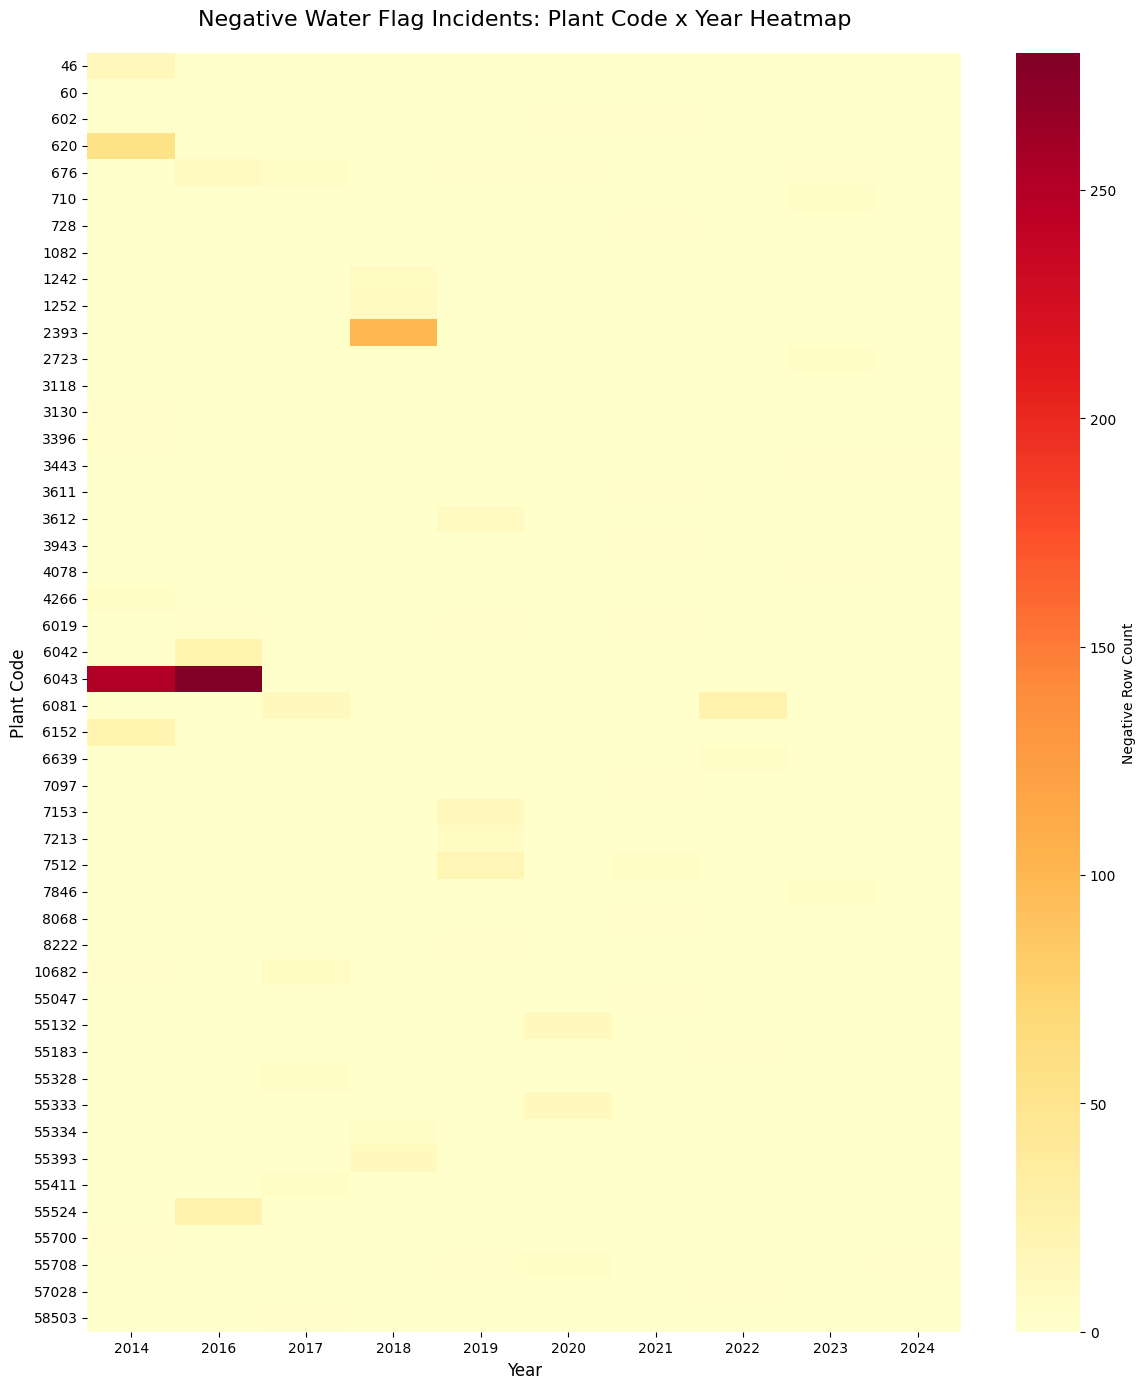

In [29]:
# 1. Spot worst offenders
melted_df[melted_df['negative_water_flag']].groupby('plant_code')[
    ['water_withdrawal_volume_million_gallons', 'water_consumption_volume_million_gallons']
].min().sort_values('water_withdrawal_volume_million_gallons')

# 2. Heatmap temporal patterns
plt.figure(figsize=(12, 14))
pivot = melted_df[melted_df['negative_water_flag']].groupby(['plant_code', 'year']).size().unstack(fill_value=0)
ax = sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Negative Row Count'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('Negative Water Flag Incidents: Plant Code x Year Heatmap', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Plant Code', fontsize=12)
plt.tight_layout()
plt.show()



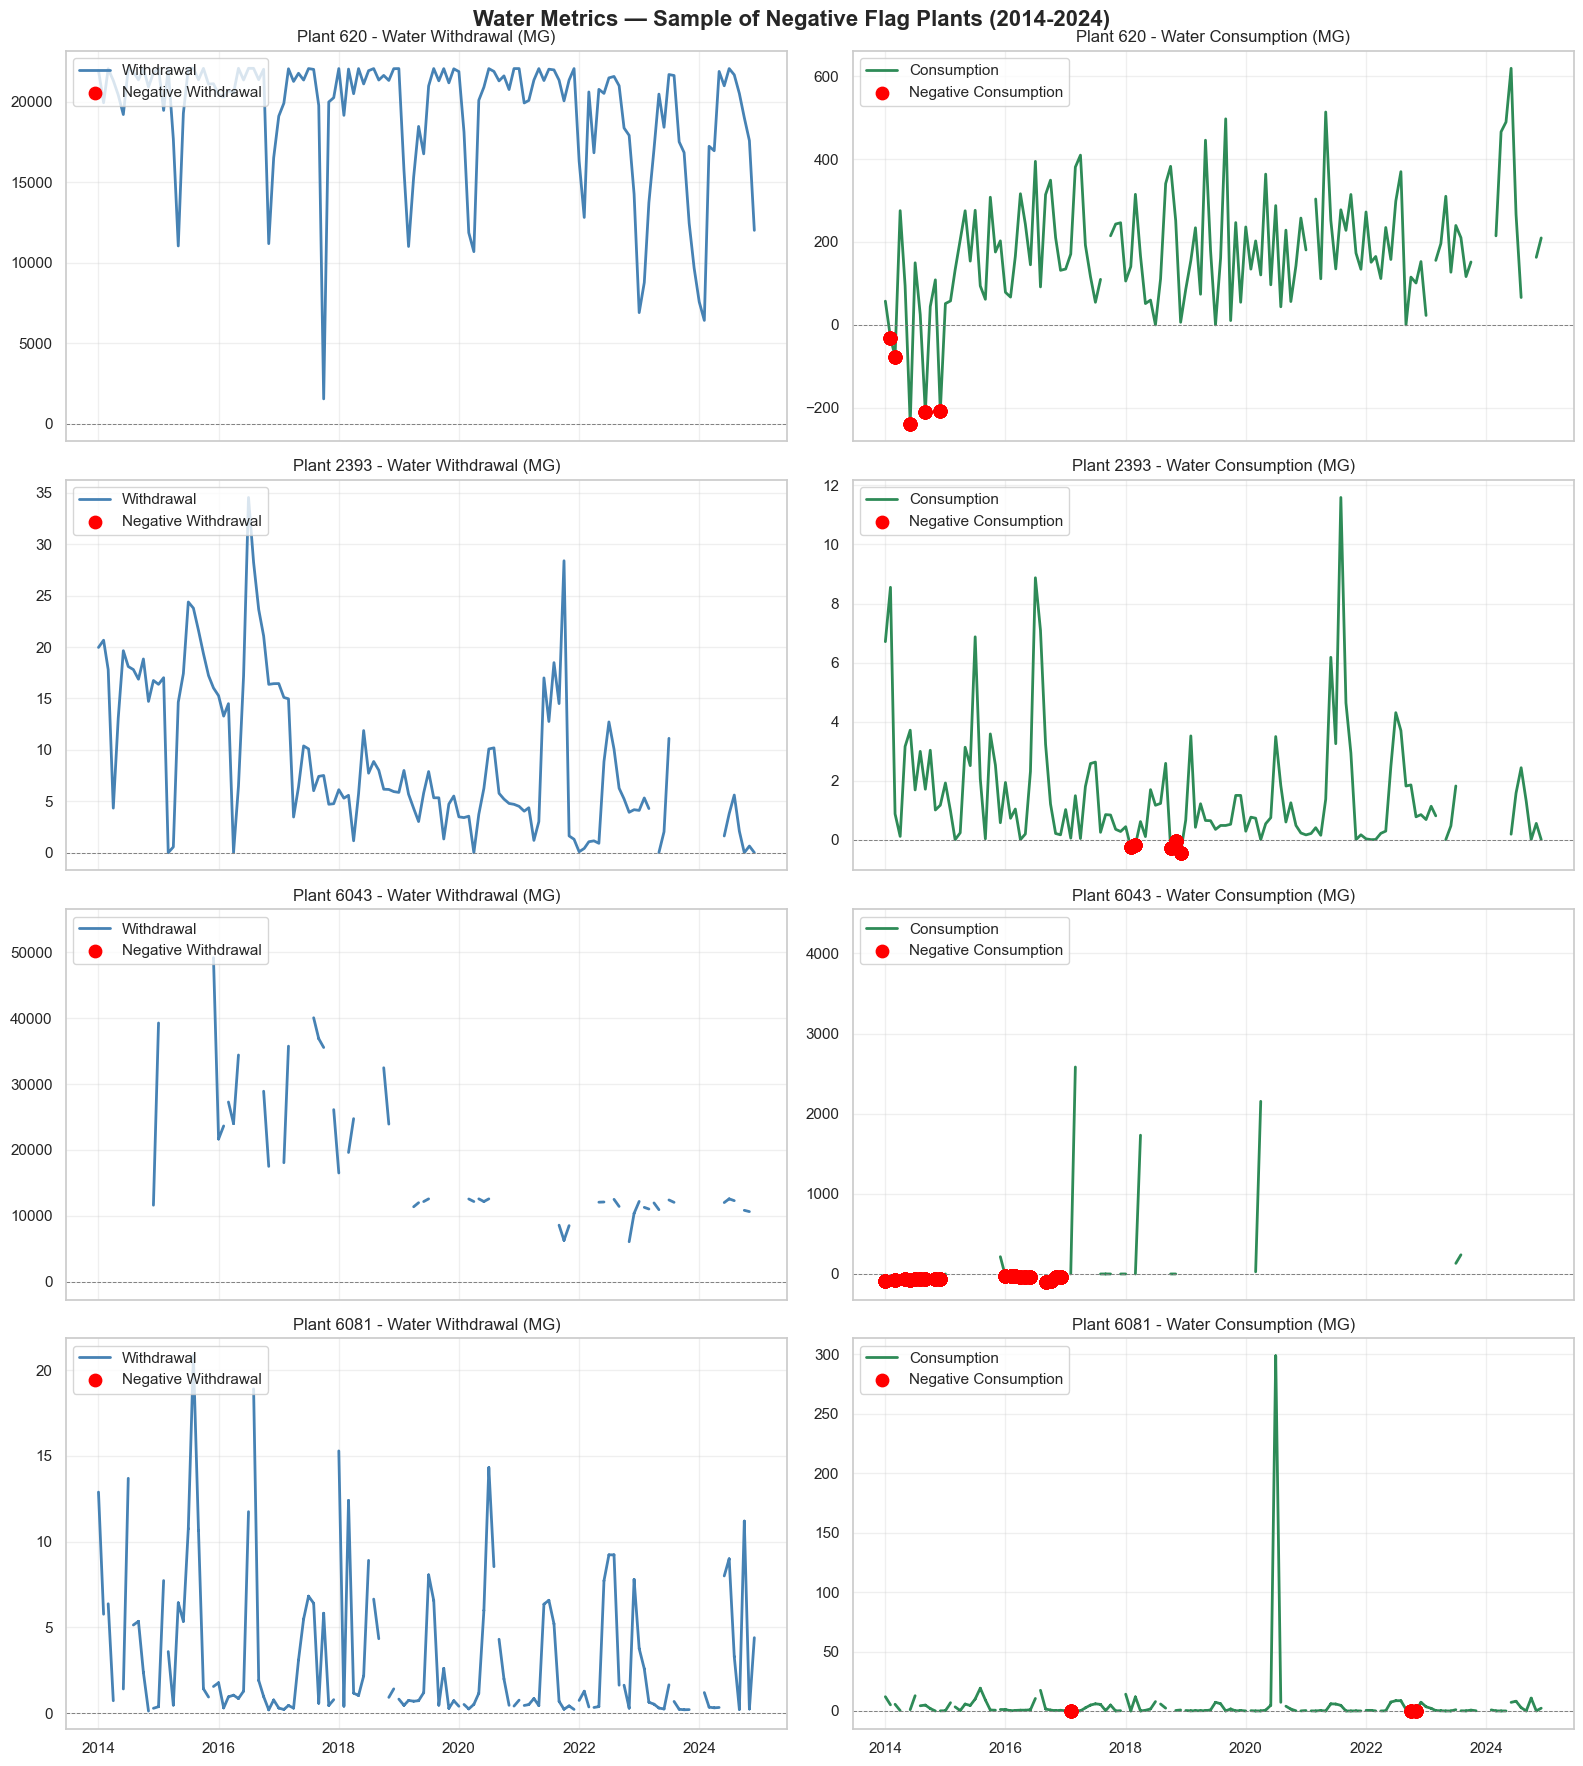

In [30]:
anomalous_plants = [620, 2393, 6043, 6081]
df_anomalous = melted_df[melted_df['plant_code'].isin(anomalous_plants)].copy()
df_anomalous['date'] = pd.to_datetime(df_anomalous[['year', 'month']].assign(day=1))

sns.set(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)

# Pre-compute negative masks (avoids legend duplication)
for i, plant in enumerate(anomalous_plants):
    plant_df = df_anomalous[df_anomalous['plant_code'] == plant].sort_values('date')
    
    # Withdrawal subplot
    axes[i, 0].plot(plant_df['date'], plant_df['water_withdrawal_volume_million_gallons'], 
                    label='Withdrawal', color='steelblue', linewidth=2)
    
    # FIXED: Separate scatter for negatives only (fixed red, single legend entry)
    neg_withdrawal = plant_df[plant_df['water_withdrawal_volume_million_gallons'] < 0]
    axes[i, 0].scatter(neg_withdrawal['date'], neg_withdrawal['water_withdrawal_volume_million_gallons'], 
                       color='red', s=80, marker='o', zorder=5, label='Negative Withdrawal')
    
    axes[i, 0].set_title(f"Plant {plant} - Water Withdrawal (MG)")
    axes[i, 0].axhline(0, linestyle='--', color='gray', linewidth=0.7)
    axes[i, 0].legend(loc='upper left')
    axes[i, 0].grid(True, alpha=0.3)

    # Consumption subplot (same fix)
    axes[i, 1].plot(plant_df['date'], plant_df['water_consumption_volume_million_gallons'], 
                    label='Consumption', color='seagreen', linewidth=2)
    
    neg_consumption = plant_df[plant_df['water_consumption_volume_million_gallons'] < 0]
    axes[i, 1].scatter(neg_consumption['date'], neg_consumption['water_consumption_volume_million_gallons'], 
                       color='red', s=80, marker='o', zorder=5, label='Negative Consumption')
    
    axes[i, 1].set_title(f"Plant {plant} - Water Consumption (MG)")
    axes[i, 1].axhline(0, linestyle='--', color='gray', linewidth=0.7)
    axes[i, 1].legend(loc='upper left')
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Water Metrics — Sample of Negative Flag Plants (2014-2024)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('/Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/anomalous_plants_water_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
# Aggregate to plant-month

df_agg = df_anomalous.groupby(['plant_code', 'date'])[['water_withdrawal_volume_million_gallons',
       'water_consumption_volume_million_gallons']].sum().reset_index()

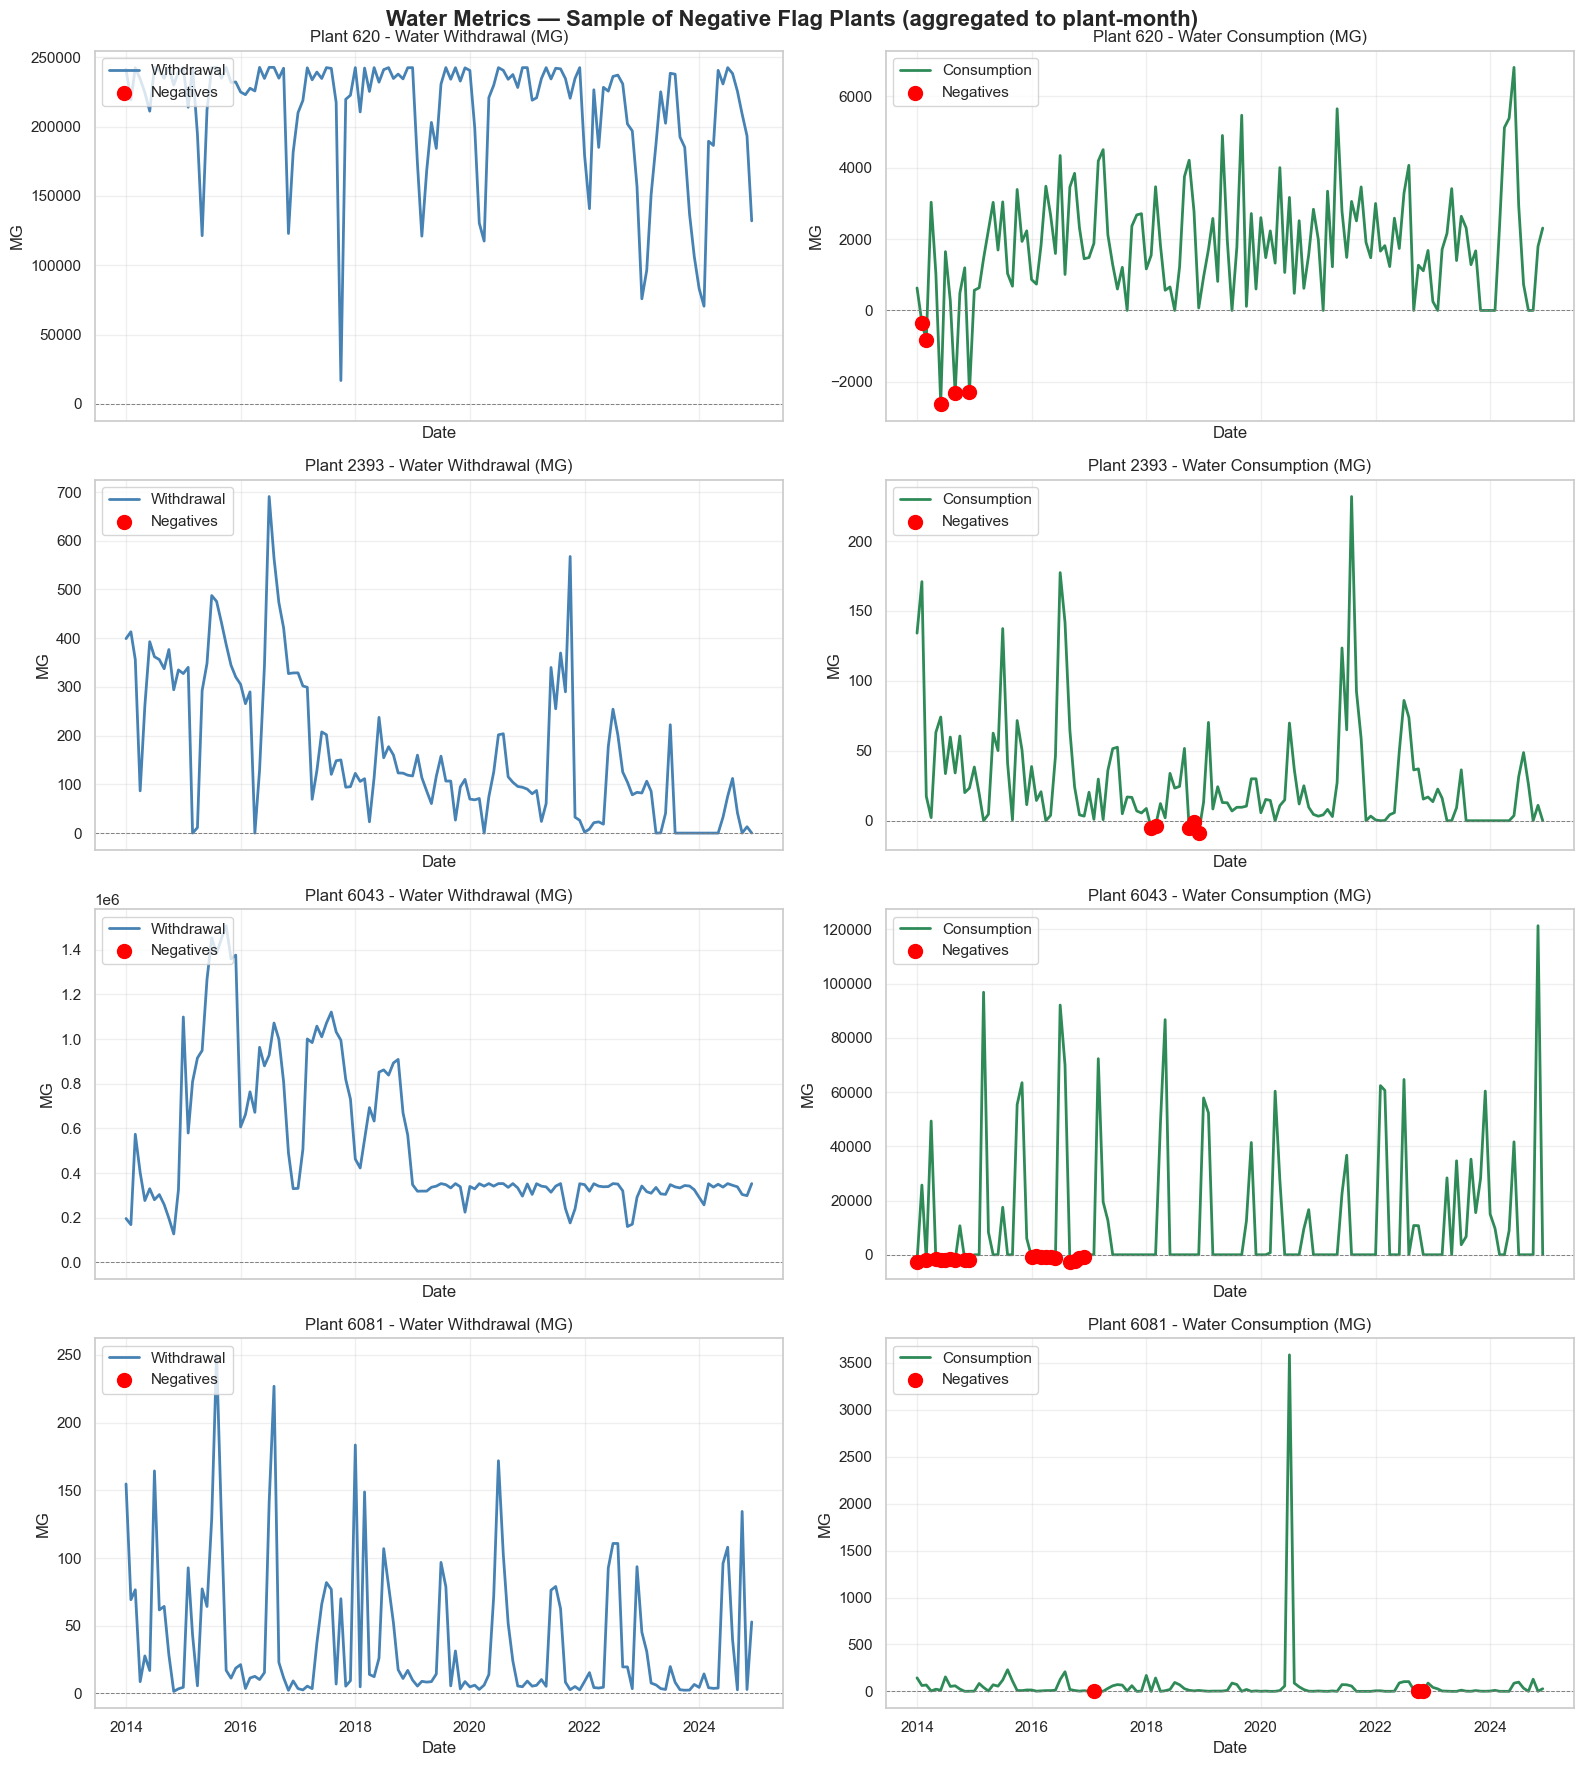

In [32]:
# --- Plot setup ---
sns.set(style="whitegrid")
fig1, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)

for i, plant in enumerate(anomalous_plants):
    plant_df = df_agg[df_agg['plant_code'] == plant].sort_values('date')
    
    # Plot Withdrawal
    axes[i, 0].plot(plant_df['date'], plant_df['water_withdrawal_volume_million_gallons'], 
                    label='Withdrawal', color='steelblue', linewidth=2)
    
    # FIXED: Filter negatives first, then scatter with FIXED red
    neg_withdrawal = plant_df[plant_df['water_withdrawal_volume_million_gallons'] < 0]
    axes[i, 0].scatter(neg_withdrawal['date'], neg_withdrawal['water_withdrawal_volume_million_gallons'], 
                       color='red', s=100, zorder=5, label='Negatives')
    
    axes[i, 0].set_title(f"Plant {plant} - Water Withdrawal (MG)")
    axes[i, 0].axhline(0, linestyle='--', color='gray', linewidth=0.7)
    axes[i, 0].legend(loc='upper left')

    # Plot Consumption  
    axes[i, 1].plot(plant_df['date'], plant_df['water_consumption_volume_million_gallons'], 
                    label='Consumption', color='seagreen', linewidth=2)
    
    # FIXED: Same for consumption
    neg_consumption = plant_df[plant_df['water_consumption_volume_million_gallons'] < 0]
    axes[i, 1].scatter(neg_consumption['date'], neg_consumption['water_consumption_volume_million_gallons'], 
                       color='red', s=100, zorder=5, label='Negatives')
    
    axes[i, 1].set_title(f"Plant {plant} - Water Consumption (MG)")
    axes[i, 1].axhline(0, linestyle='--', color='gray', linewidth=0.7)
    axes[i, 1].legend(loc='upper left')

# Final layout
for ax in axes.flatten():
    ax.set_ylabel('MG')
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)

plt.suptitle('Water Metrics — Sample of Negative Flag Plants (aggregated to plant-month)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()                                                          
plt.savefig('/Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/anomalous_plants_water_metrics_agg_1.png', dpi=150, bbox_inches='tight')                                                          
plt.show()


### **Decision:** 
Remove all rows where either water metric is negative.

In [33]:
melted_df.drop(melted_df[melted_df['negative_water_flag'] == True].index, inplace=True)

## 3c) Neither Water Metric

In [34]:
# Subset the 'neither' rows
neither_df = melted_df[melted_df['water_metric_flag'] == 'neither']

# How many rows are we talking about?
print(f"Total 'neither' rows: {len(neither_df):,}")

# How many unique plant_codes?
unique_plants = neither_df['plant_code'].nunique()
print(f"Unique plant_codes with neither metric: {unique_plants:,}")

# How many unique states?
unique_states = neither_df['state'].nunique()
print(f"Unique states with neither metric: {unique_states:,}")


Total 'neither' rows: 307,563
Unique plant_codes with neither metric: 688
Unique states with neither metric: 49


In [35]:
num_summary, cat_summary = column_profile(neither_df)

In [36]:
cat_summary

,unique_count,mode,mode_count,mode_pct,missing_count,missing_pct
column,,,,,,
state,49,TX,35242,11.46,0,0.00
plant_name,709,Motiva Enterprises Port Arthur Refinery,10752,3.50,0,0.00
generator_id,409,1,35616,11.58,180,0.06
boiler_id,452,1,28828,9.37,156,0.05
cooling_id,360,1,58213,18.93,24,0.01
generator_primary_technology,16,Natural Gas Fired Combined Cycle,142747,46.41,180,0.06
cooling_type_1_860,10,(RI) Recirculate: Induced Draft,117900,38.33,3652,1.19
cooling_type_2_860,9,NaN,300582,97.73,300582,97.73
cooling_type_923,10,NaN,207658,67.52,207658,67.52


In [37]:
def compare_distributions(df_a, df_b, column, label_a="group_a",              
label_b="group_b"):                                                           
    """Compare value distributions between two subsets"""                     
    dist_a = df_a[column].value_counts(dropna=False,                          
normalize=True).mul(100).round(1)                                             
    dist_b = df_b[column].value_counts(dropna=False,                          
normalize=True).mul(100).round(1)                                             
                                                                                
    comparison = pd.DataFrame({                                               
        f'{label_a}_pct': dist_a,                                             
        f'{label_b}_pct': dist_b                                              
    }).fillna(0)                                                              
    comparison['diff'] = (comparison[f'{label_a}_pct'] -                      
comparison[f'{label_b}_pct']).round(1)                                        
    return comparison                                                         
                                                                                                                                                                                                                                                                                                                
# Compare key columns                                                         
other_df = melted_df[~melted_df.index.isin(neither_df.index)].reset_index(drop=True)

for col in ['cooling_type_923', 'water_type', 'water_source',
            'generator_primary_energy_source_code',
            'generator_prime_mover_code', 'technology_type']:
    print(f"=== {col}: Neither Water Metrics vs All Other Rows ===")
    print(compare_distributions(
        neither_df,
        other_df,
        col,
        label_a="neither_water",
        label_b="all_other"
    ).sort_values('diff', ascending=False))
    print()

=== cooling_type_923: Neither Water Metrics vs All Other Rows ===
                  neither_water_pct  all_other_pct  diff
cooling_type_923                                        
NaN                            67.5            0.0  67.5
DC                             14.9            0.1  14.8
OT                              0.8            0.0   0.8
HRF                             0.0            0.0   0.0
RE                              0.0            0.0   0.0
RF                              0.1            0.4  -0.3
HRI                             0.0            0.4  -0.4
OC                              0.1            1.8  -1.7
RN                              0.2            3.3  -3.1
RC                              0.4            8.9  -8.5
ON                              7.1           21.6 -14.5
RI                              8.9           63.5 -54.6

=== water_type: Neither Water Metrics vs All Other Rows ===
            neither_water_pct  all_other_pct  diff
water_type              

## 3c1) Remove structurally explained rows with neither water metric

In [38]:
mask = (
    (melted_df['water_metric_flag'] == 'neither') & 
    (melted_df['cooling_type_923'].isna() | (melted_df['cooling_type_923'] == 'DC'))
)

melted_df.drop(melted_df[mask].index, inplace=True)
melted_df.reset_index(drop=True, inplace=True)

## 3c2) Explore remaining rows with neither water metric: plant-level investigation 

In [39]:
# Subset the 'neither' rows
neither_df_2 = melted_df[melted_df['water_metric_flag'] == 'neither']

# How many rows are we talking about?
print(f"Total 'neither' rows: {len(neither_df_2):,}")

# How many unique plant_codes?
unique_plants_2 = neither_df_2['plant_code'].nunique()
print(f"Unique plant_codes with neither metric: {unique_plants_2:,}")

# How many unique states?
unique_states_2 = neither_df_2['state'].nunique()
print(f"Unique states with neither metric: {unique_states_2:,}")


Total 'neither' rows: 53,984
Unique plant_codes with neither metric: 387
Unique states with neither metric: 46


In [40]:
neither_df_2.groupby('plant_code').size().sort_values(ascending=False).head(50)

plant_code
54104    9600
56163    3264
10360    3192
3469     2911
3152     2112
50243    1560
2917     1144
2098      996
55480     876
613       780
2322      738
54676     720
55097     720
1378      648
1745      587
3264      555
59773     522
50189     504
3096      444
50707     420
3443      420
55470     360
2480      351
56237     348
1507      336
2161      330
628       325
54627     294
50397     288
55965     288
55333     276
2964      266
6090      264
10075     252
55221     252
2367      245
6013      234
113       231
10397     225
50406     222
2393      220
4072      216
3006      213
2718      211
3470      211
55419     200
3251      192
3405      192
8906      188
1831      186
dtype: int64

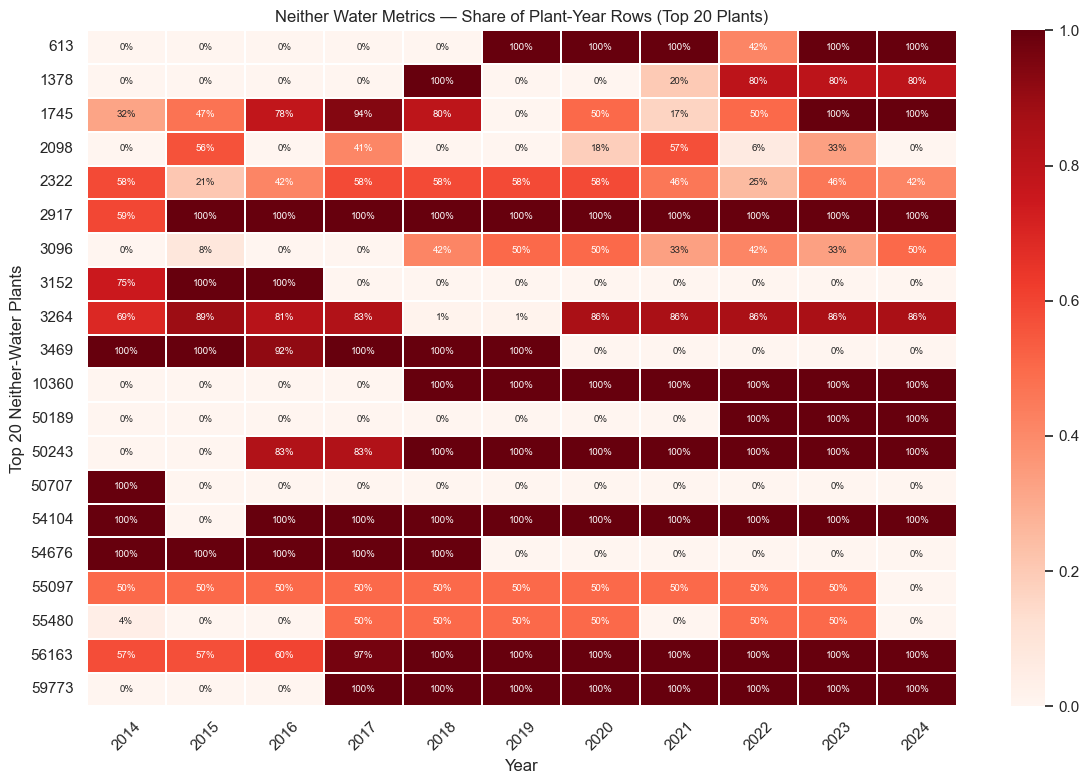

In [42]:
top_neither_plants = (
      neither_df_2.groupby('plant_code')
      .size()
      .sort_values(ascending=False)
      .head(20)
      .index
  )

neither_counts = (
    neither_df_2[neither_df_2['plant_code'].isin(top_neither_plants)]
    .groupby(['plant_code', 'year'])
    .size()
)

total_counts = (
    melted_df[melted_df['plant_code'].isin(top_neither_plants)]
    .groupby(['plant_code', 'year'])
    .size()
)

pivot = (neither_counts / total_counts).fillna(0).unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='Reds', linewidths=0.3, vmin=0, vmax=1,
            fmt='.0%', annot=True, annot_kws={'size': 7})
plt.title('Neither Water Metrics — Share of Plant-Year Rows (Top 20 Plants)')
plt.xlabel('Year')
plt.ylabel('Top 20 Neither-Water Plants')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### 1. Hypothesis: SCD Type 2 Dimensions

In [43]:
sample_plants = [                                                             
      (10360, "turns 'off' in 2018"),
      (54676, "turns 'on' in 2019"),                                            
      (2322, "missingness distributed throughout"),
      (54104, "data only for 2015")
  ]
cols_to_check = ['technology_type', 'generator_primary_energy_source_code',
                   'cooling_system_type', 'sector', 'relationship_type',
  'utility_id', 'generator_status', 'boiler_status', 'cooling_status']

for plant, description in sample_plants:
      plant_data = melted_df[melted_df['plant_code'] == plant]
      print(f"\n=== Plant {plant} ({description}) ===")
      for col in cols_to_check:
          yearly = plant_data.groupby(['year',
  'water_metric_flag'])[col].unique()
          print(f"\n{col}:\n{yearly}")


=== Plant 10360 (turns 'off' in 2018) ===

technology_type:
year  water_metric_flag
2014  both                 [steam_turbine]
2018  neither              [steam_turbine]
2019  neither              [steam_turbine]
2020  neither              [steam_turbine]
2021  neither              [steam_turbine]
2022  neither              [steam_turbine]
2023  neither              [steam_turbine]
2024  neither              [steam_turbine]
Name: technology_type, dtype: object

generator_primary_energy_source_code:
year  water_metric_flag
2014  both                     [BIT]
2018  neither              [BIT, NG]
2019  neither              [BIT, NG]
2020  neither              [BIT, NG]
2021  neither              [NG, BIT]
2022  neither              [NG, BIT]
2023  neither              [NG, BIT]
2024  neither              [NG, BIT]
Name: generator_primary_energy_source_code, dtype: object

cooling_system_type:
year  water_metric_flag
2014  both                 [Open]
2018  neither              [Open]
201

#### Result: No clean SCD pattern was found.
#### 2. Hypothesis: Fuel-Type and Sector-Related Missingness

In [44]:
plant_2322 = melted_df[melted_df['plant_code'] == 2322]

for col in ['cooling_type_923', 'cooling_system_type', 'cooling_id',
              'boiler_id', 'generator_id']:
      print(f"=== {col} ===")
      print(compare_distributions(
          plant_2322[plant_2322['water_metric_flag'] == 'neither'],
          plant_2322[plant_2322['water_metric_flag'] == 'both'],
          col,
          label_a='neither',
          label_b='both'
      ))
      print()

=== cooling_type_923 ===
                  neither_pct  both_pct  diff
cooling_type_923                             
RI                      100.0     100.0   0.0

=== cooling_system_type ===
                     neither_pct  both_pct  diff
cooling_system_type                             
Closed                     100.0     100.0   0.0

=== cooling_id ===
            neither_pct  both_pct  diff
cooling_id                             
10                 51.2      48.9   2.3
9                  48.8      51.1  -2.3

=== boiler_id ===
           neither_pct  both_pct  diff
boiler_id                             
5                 25.6      24.5   1.1
6                 25.6      24.5   1.1
7                 24.4      25.5  -1.1
8                 24.4      25.5  -1.1

=== generator_id ===
              neither_pct  both_pct  diff
generator_id                             
10                   17.1      16.3   0.8
9                    16.3      17.0  -0.7
GT5                  17.1      16.3   

In [45]:
print(compare_distributions(
      neither_df_2,                                                                                  
      melted_df[~melted_df.index.isin(neither_df_2.index)],
      'sector',
      label_a='neither',
      label_b='all_other'
  ).sort_values('diff', ascending=False))

print(compare_distributions(
      neither_df_2,
      melted_df[~melted_df.index.isin(neither_df_2.index)],
      'generator_primary_energy_source_code', 
      label_a='neither',
      label_b='all_other'
  ).sort_values('diff', ascending=False))

                    neither_pct  all_other_pct  diff
sector                                              
Industrial CHP             34.0           17.3  16.7
IPP Non-CHP                27.5           27.0   0.5
NaN                         0.5            0.0   0.5
Commercial Non-CHP          0.0            0.0   0.0
Industrial Non-CHP          0.0            0.0   0.0
IPP CHP                     4.2           10.2  -6.0
Electric Utility           33.7           45.3 -11.6
                                      neither_pct  all_other_pct  diff
generator_primary_energy_source_code                                  
BLQ                                          19.5            2.1  17.4
BIT                                          21.3            9.9  11.4
WDS                                           1.7            0.3   1.4
RFO                                           1.7            0.8   0.9
SUB                                           7.9            7.2   0.7
AB                        

In [46]:
neither_df_2['combined_heat_and_power_generator'].value_counts(dropna=False)

combined_heat_and_power_generator
N      34189
Y      19792
NaN        3
Name: count, dtype: int64

In [47]:
neither_df_2.shape

(53984, 71)

In [48]:
melted_df.shape

(662787, 71)

## 3c3: Conclusion — Remove Rows with Neither Water Metric

In [49]:
# Keep only rows with at least one water metric
analysis_df = melted_df[melted_df['water_metric_flag'] != 'neither'].copy()

# Check sizes
melted_df['water_metric_flag'].value_counts()
analysis_df['water_metric_flag'].value_counts()


water_metric_flag
both                563180
withdrawal_only      41922
consumption_only      3701
Name: count, dtype: int64

In [50]:
analysis_df.shape

(608803, 71)

---
# 4. Save `analysis_ready_df.csv`

In [53]:
save_df(analysis_df, 'analysis_ready_df.csv')

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/analysis_ready_df.csv


PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/analysis_ready_df.csv')